C:\Users\jekim\AppData\Local\Temp\ipykernel_21140\609444640.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')


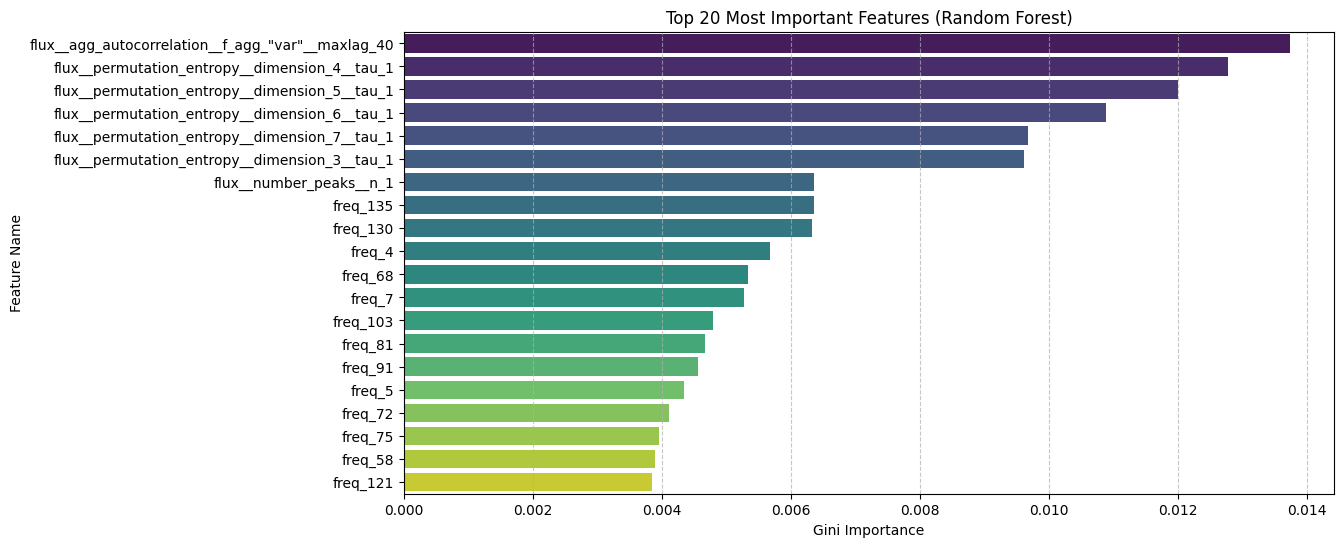

In [19]:
import joblib
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt 


rf_model = joblib.load('../../models/rf_baseline.pkl')

features_df = pd.read_csv('../../data/processed/clean_features.csv')
fft_df = pd.read_csv('../../data/processed/fft_features.csv')
df_merged = pd.merge(features_df, fft_df, on=['id', 'class'])
X_columns = df_merged.drop(columns=['id', 'class']).columns

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_columns,
    'Importance': importances
})

top_20_features = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.xlabel('Gini Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()